In [1]:
import cv2
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
print(cv2.__version__)

4.12.0


In [2]:
eye_cascade = cv2.CascadeClassifier('haarcascade_eye.xml')

In [21]:
left = []
right = []
img_arr = [i for i in range(0,5)]
test_img_arr = [i for i in range(0,10)]

for i in range(1,11):
    img2 = cv2.imread('img/test'+str(i)+'.jpg')
    test_img_arr[i-1] = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)


for i in range(1,6):
    img = cv2.imread('img/train'+str(i)+'.jpg')
    img_arr[i-1] = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    file = open('img/train' + str(i) + '.gnd', 'r')
    l = file.readline()
    r = file.readline()

    (glx, gly) = int(l.split(" ")[1].split(',')[0]), int(l.split(" ")[1].split(',')[1])
    (grx, gry) = int(r.split(" ")[1].split(',')[0]), int(r.split(" ")[1].split(',')[1])

    #print(glx, gly)
    #print(grx, gry)

    left.append((glx,gly))
    right.append((grx,gry))

In [22]:
def measureDistance(lx,ly, glx,gly,  rx,ry, grx,gry):
    dl, dr = 10.0,10.0

    # applied pythagorean theorem to calculate the distance
    
    if lx is not None and ly is not None:
        dl = ((glx - lx)**2 + (gly - ly)**2) ** .5

    if rx is not None and ry is not None:
        dr = ((grx - rx) ** 2 + (gry - ry) ** 2) ** .5

    return dl, dr

In [32]:
# create a function to detect eyes
#######################################
# Problem 6: default values for scaleFactor and minNeighbors are optimized values from Problem 5
#######################################
def detect_eyes(img, scaleFactor=1.92, minNeighbors=9):
    eye_img = img.copy()
    height, width, channels = eye_img.shape

    eye_rect = eye_cascade.detectMultiScale(eye_img, scaleFactor=scaleFactor, minNeighbors=minNeighbors,
                                            minSize=(int(width * 0.1), int(height * 0.1)))

    #print(eye_rect)
    eye_rect = sorted(eye_rect, key=lambda e: e[2]*e[3], reverse=False)
    #print('sorted eye_rect', eye_rect)
    eye_rect = eye_rect[:2]

    results = []
    for (x,y,w,h) in eye_rect:
        # red box for eyes
        cv2.rectangle(eye_img, (x,y), (x+w, y+h), (255,0,0), 1)
        cx, cy = x+w//2, y+h//2

        results.append(cx)
        results.append(cy)

        cv2.rectangle(eye_img, (cx-2,cy-2), (cx+2,cy+2), (0,255,0), 1)

        plt.imshow(eye_img)


    return results

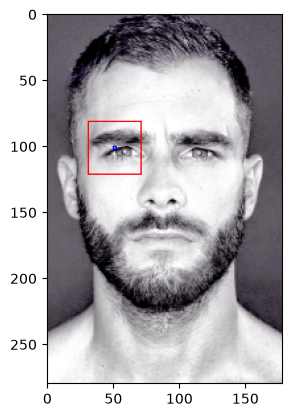

In [24]:
# 3d array to store results (avg distances)
r = [[[0 for i in range(10)] for j in range(100)] for k in range(5)]


for i in range(0,5):
    for scaleFactor in range(101, 201, 1):
        for minNeighbors in range(1, 11, 1):
            results = detect_eyes(img_arr[i], scaleFactor/100, minNeighbors)

            #print('length: ', len(results))

            lx,ly,rx,ry = None,None,None,None

            if len(results) == 4:
                lx,ly,rx,ry = results
            elif len(results) == 2:
                lx,ly = results
                
            glx, gly = left[i]
            grx, gry = right[i]

            
            dl, dr = measureDistance(lx, ly, glx,gly, rx, ry, grx, gry)
            
            avg = (dl+dr)/2

            r[i][scaleFactor-101][minNeighbors-1] = avg

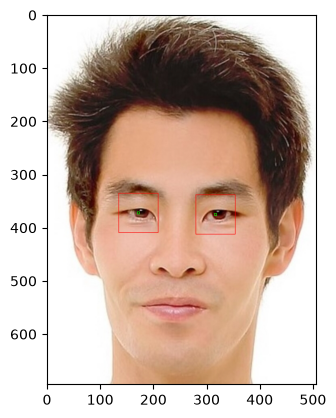

In [33]:
#########################################
#  Use only for Problem 6
#########################################

# 3d array to store results (avg distances)
r = [[[0 for i in range(1)] for j in range(1)] for k in range(10)]


for i in range(0,9):
    # uncomment the following for problem 6:
    results = detect_eyes(test_img_arr[i])
    #results = detect_eyes(img_arr[i], scaleFactor/100, minNeighbors)

    #print('length: ', len(results))

    lx,ly,rx,ry = None,None,None,None

    if len(results) == 4:
        lx,ly,rx,ry = results
    elif len(results) == 2:
        lx,ly = results

    
    

In [25]:

df = pd.DataFrame(index=[k for k in range(1,11,1)],columns=[j/100 for j in range(101,201,1)])
avg = [[0 for j in range(100)] for i in range(10)]



for minNeighbors in range(1, 11, 1):
    for scaleFactor in range(101, 201, 1):
        for i in range(0,5):
            avg[minNeighbors-1][scaleFactor-101] += r[i][scaleFactor-101][minNeighbors-1]

        print(f"minNeighbors: {minNeighbors-1}, scaleFactor: {scaleFactor-101}, avg: {avg[minNeighbors-1][scaleFactor-101]/5}")
        df.iat[minNeighbors-1, scaleFactor-101] = (avg[minNeighbors-1][scaleFactor-101] / 5)

df.to_excel('eye_detection_results.xlsx', header=True)

minNeighbors: 0, scaleFactor: 0, avg: 1023.2064864482636
minNeighbors: 0, scaleFactor: 1, avg: 1035.4667081219457
minNeighbors: 0, scaleFactor: 2, avg: 1027.393110137574
minNeighbors: 0, scaleFactor: 3, avg: 1035.4601304761986
minNeighbors: 0, scaleFactor: 4, avg: 1029.29412657916
minNeighbors: 0, scaleFactor: 5, avg: 1033.7493790858878
minNeighbors: 0, scaleFactor: 6, avg: 1038.780658430179
minNeighbors: 0, scaleFactor: 7, avg: 1036.8411882932419
minNeighbors: 0, scaleFactor: 8, avg: 1041.3774052170124
minNeighbors: 0, scaleFactor: 9, avg: 1028.5675678781638
minNeighbors: 0, scaleFactor: 10, avg: 1033.3064482134992
minNeighbors: 0, scaleFactor: 11, avg: 1037.2386020678748
minNeighbors: 0, scaleFactor: 12, avg: 1043.229365646232
minNeighbors: 0, scaleFactor: 13, avg: 1036.5777640256204
minNeighbors: 0, scaleFactor: 14, avg: 1042.7385999251242
minNeighbors: 0, scaleFactor: 15, avg: 1033.1592651628557
minNeighbors: 0, scaleFactor: 16, avg: 1036.9474358443217
minNeighbors: 0, scaleFactor:

In [26]:
# Problem 5
# Find the position of the minimum value
min_value = df.min().min()  # Minimum value in the entire DataFrame
min_pos = df.stack().idxmin()  # Returns (row_index, column_name) of min value

print(f"Minimum value: {min_value}")
print(f"Row index (minNeighbors): {min_pos[0]}")
print(f"Column name (scaleFactor): {min_pos[1]}")

Minimum value: 216.0154583599978
Row index (minNeighbors): 9
Column name (scaleFactor): 1.92


In [ ]:
#######################################
# Summary
#######################################
# The eye_detector function was modified to be scanned with
# different 'scaleFactors' and 'minNeighbors' variables.
# This resulted in an table from which a minimum combination 
# of scaleFactor and minNeighbors was selected.  The training 
# was done with five training images.  The values that produced 
# were inputted back into the eye_detector function as defaults.
#
# It is important to throughly scan the search space to find
# the minimum combination.  Other factors that could have
# been considered for scanning is the minSize and maxSize.
# At this moment, the minSize and maxSize is still a best
# guess.  Because of this, the search cannot be considered
# as conclusive.  Also, the data for training was minimal,
# consisting of only five images and testing with 10 images.
